In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/rt_sem2_data.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')   # ⭐ THIS LINE

# log returns
returns = np.log(df / df.shift(1))
returns = returns.dropna()
returns.columns

c:\Users\sivac\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Index(['CL=F', 'DX-Y.NYB', 'EURUSD=X', 'GLD', 'IWM', 'JPYUSD=X', 'QQQ', 'SPY',
       'TLT', 'IRX', 'TNX', 'VIX'],
      dtype='object')

In [ ]:
#Creating target variable
h = 5
#Delta = crash threshold
delta = -0.01

spy_future_return = returns['SPY'].rolling(window=h).sum().shift(-h)

returns['target'] = (spy_future_return <= delta).astype(int)
returns = returns.dropna()
returns.columns


Index(['CL=F', 'DX-Y.NYB', 'EURUSD=X', 'GLD', 'IWM', 'JPYUSD=X', 'QQQ', 'SPY',
       'TLT', 'IRX', 'TNX', 'VIX', 'target'],
      dtype='object')

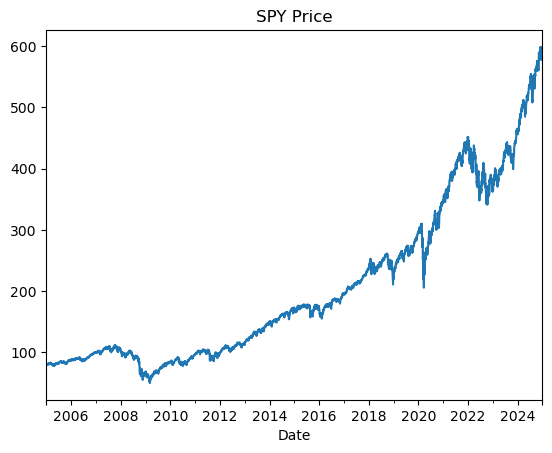

In [ ]:
# SPY price trend
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['SPY'])
plt.title('SPY Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

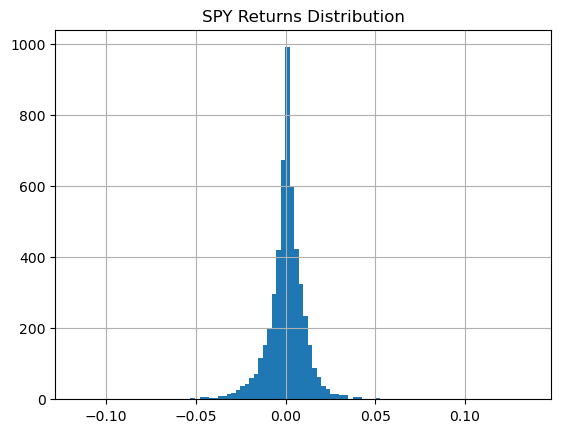

In [5]:
#Returns distribution
returns['SPY'].hist(bins=100)
plt.title("SPY Returns Distribution")
plt.show()

<Axes: >

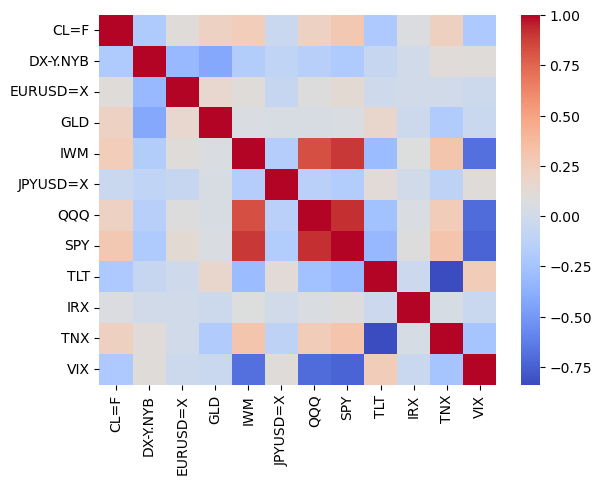

In [6]:
#Correlation Analysis
import seaborn as sns
corr = returns.drop(columns=['target']).corr()
sns.heatmap(corr, cmap='coolwarm')

In [7]:
#Checking for class imbalance
returns['target'].value_counts(normalize=True)

#Class imbalance present

target
0    0.77782
1    0.22218
Name: proportion, dtype: float64

In [8]:
#Rolling stats for time series

#creating new features using the last 10 days of data.
returns['SPY_volatility'] = returns['SPY'].rolling(10).std() #measures volatility (TS)
#My understanding: How risky has the market been recently?


returns['SPY_mean'] = returns['SPY'].rolling(10).mean() #measures trend
#My understanding: Is market going up or down recently?

In [9]:
#Lag Features
for lag in range(1, 6):
    returns[f'SPY_lag_{lag}'] = returns['SPY'].shift(lag)

'''
.shift(1):Yesterday’s return
.shift(2):Return 2 days ago
.shift(5):Return 5 days ago
'''

'\n.shift(1):Yesterday’s return\n.shift(2):Return 2 days ago\n.shift(5):Return 5 days ago\n'

In [10]:
'''At time t, you give model:
yesterday’s return
day before yesterday’s return'''

'At time t, you give model:\nyesterday’s return\nday before yesterday’s return'

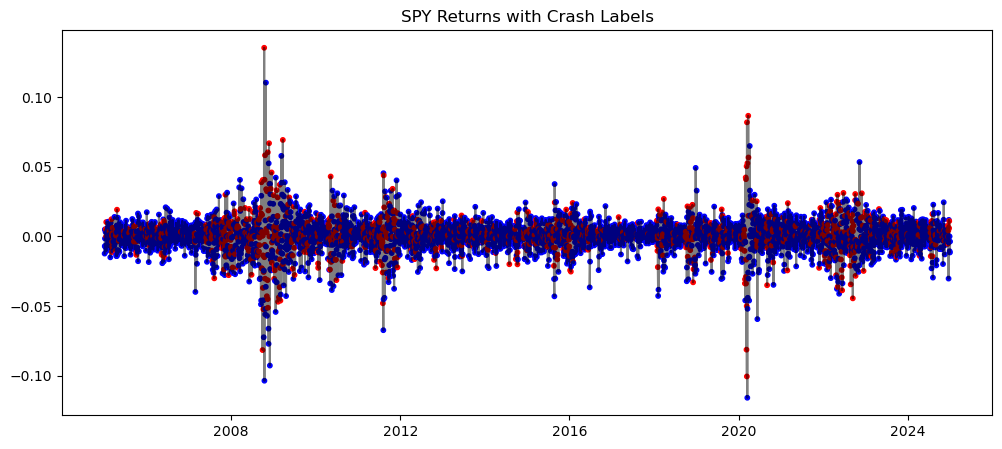

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Line plot
plt.plot(returns.index, returns['SPY'], color='black', alpha=0.5, label='SPY Returns')

# Scatter with 2 distinct colors
colors = returns['target'].map({0: 'blue', 1: 'red'})

plt.scatter(returns.index, returns['SPY'],
            c=colors, s=10)

plt.title("SPY Returns with Crash Labels")
plt.show()

In [12]:
#number of crash events
returns['target'].sum() 

1158

In [13]:
print(returns.groupby('target')['SPY_volatility'].mean())
print(returns.groupby('target')['VIX'].mean())
print(returns.groupby('target')['SPY_mean'].mean())

'''My understanding:

VIX: Market’s expectation of future volatility
SPY_volatility: Actual realized past volatility
'''

target
0    0.008854
1    0.011511
Name: SPY_volatility, dtype: float64
target
0    0.000158
1   -0.000352
Name: VIX, dtype: float64
target
0    0.000499
1   -0.000015
Name: SPY_mean, dtype: float64


'My understanding:\n\nVIX: Market’s expectation of future volatility\nSPY_volatility: Actual realized past volatility\n'

<Axes: xlabel='SPY_volatility', ylabel='Density'>

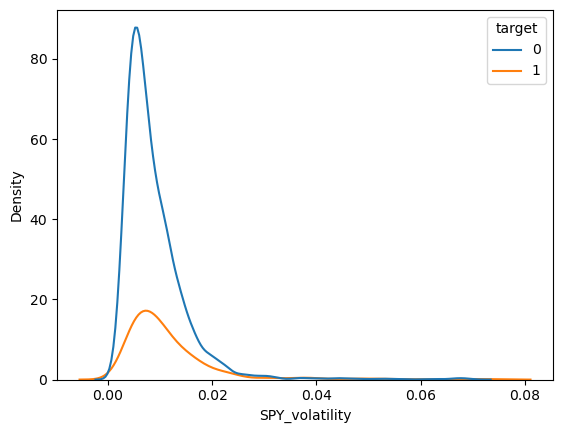

In [14]:
import seaborn as sns

sns.kdeplot(data=returns, x='SPY_volatility', hue='target')

Interpretation:

Crash distribution is slightly more to the right

Non-crash → lower volatility (mostly)

Crash → relatively higher volatility (on average)

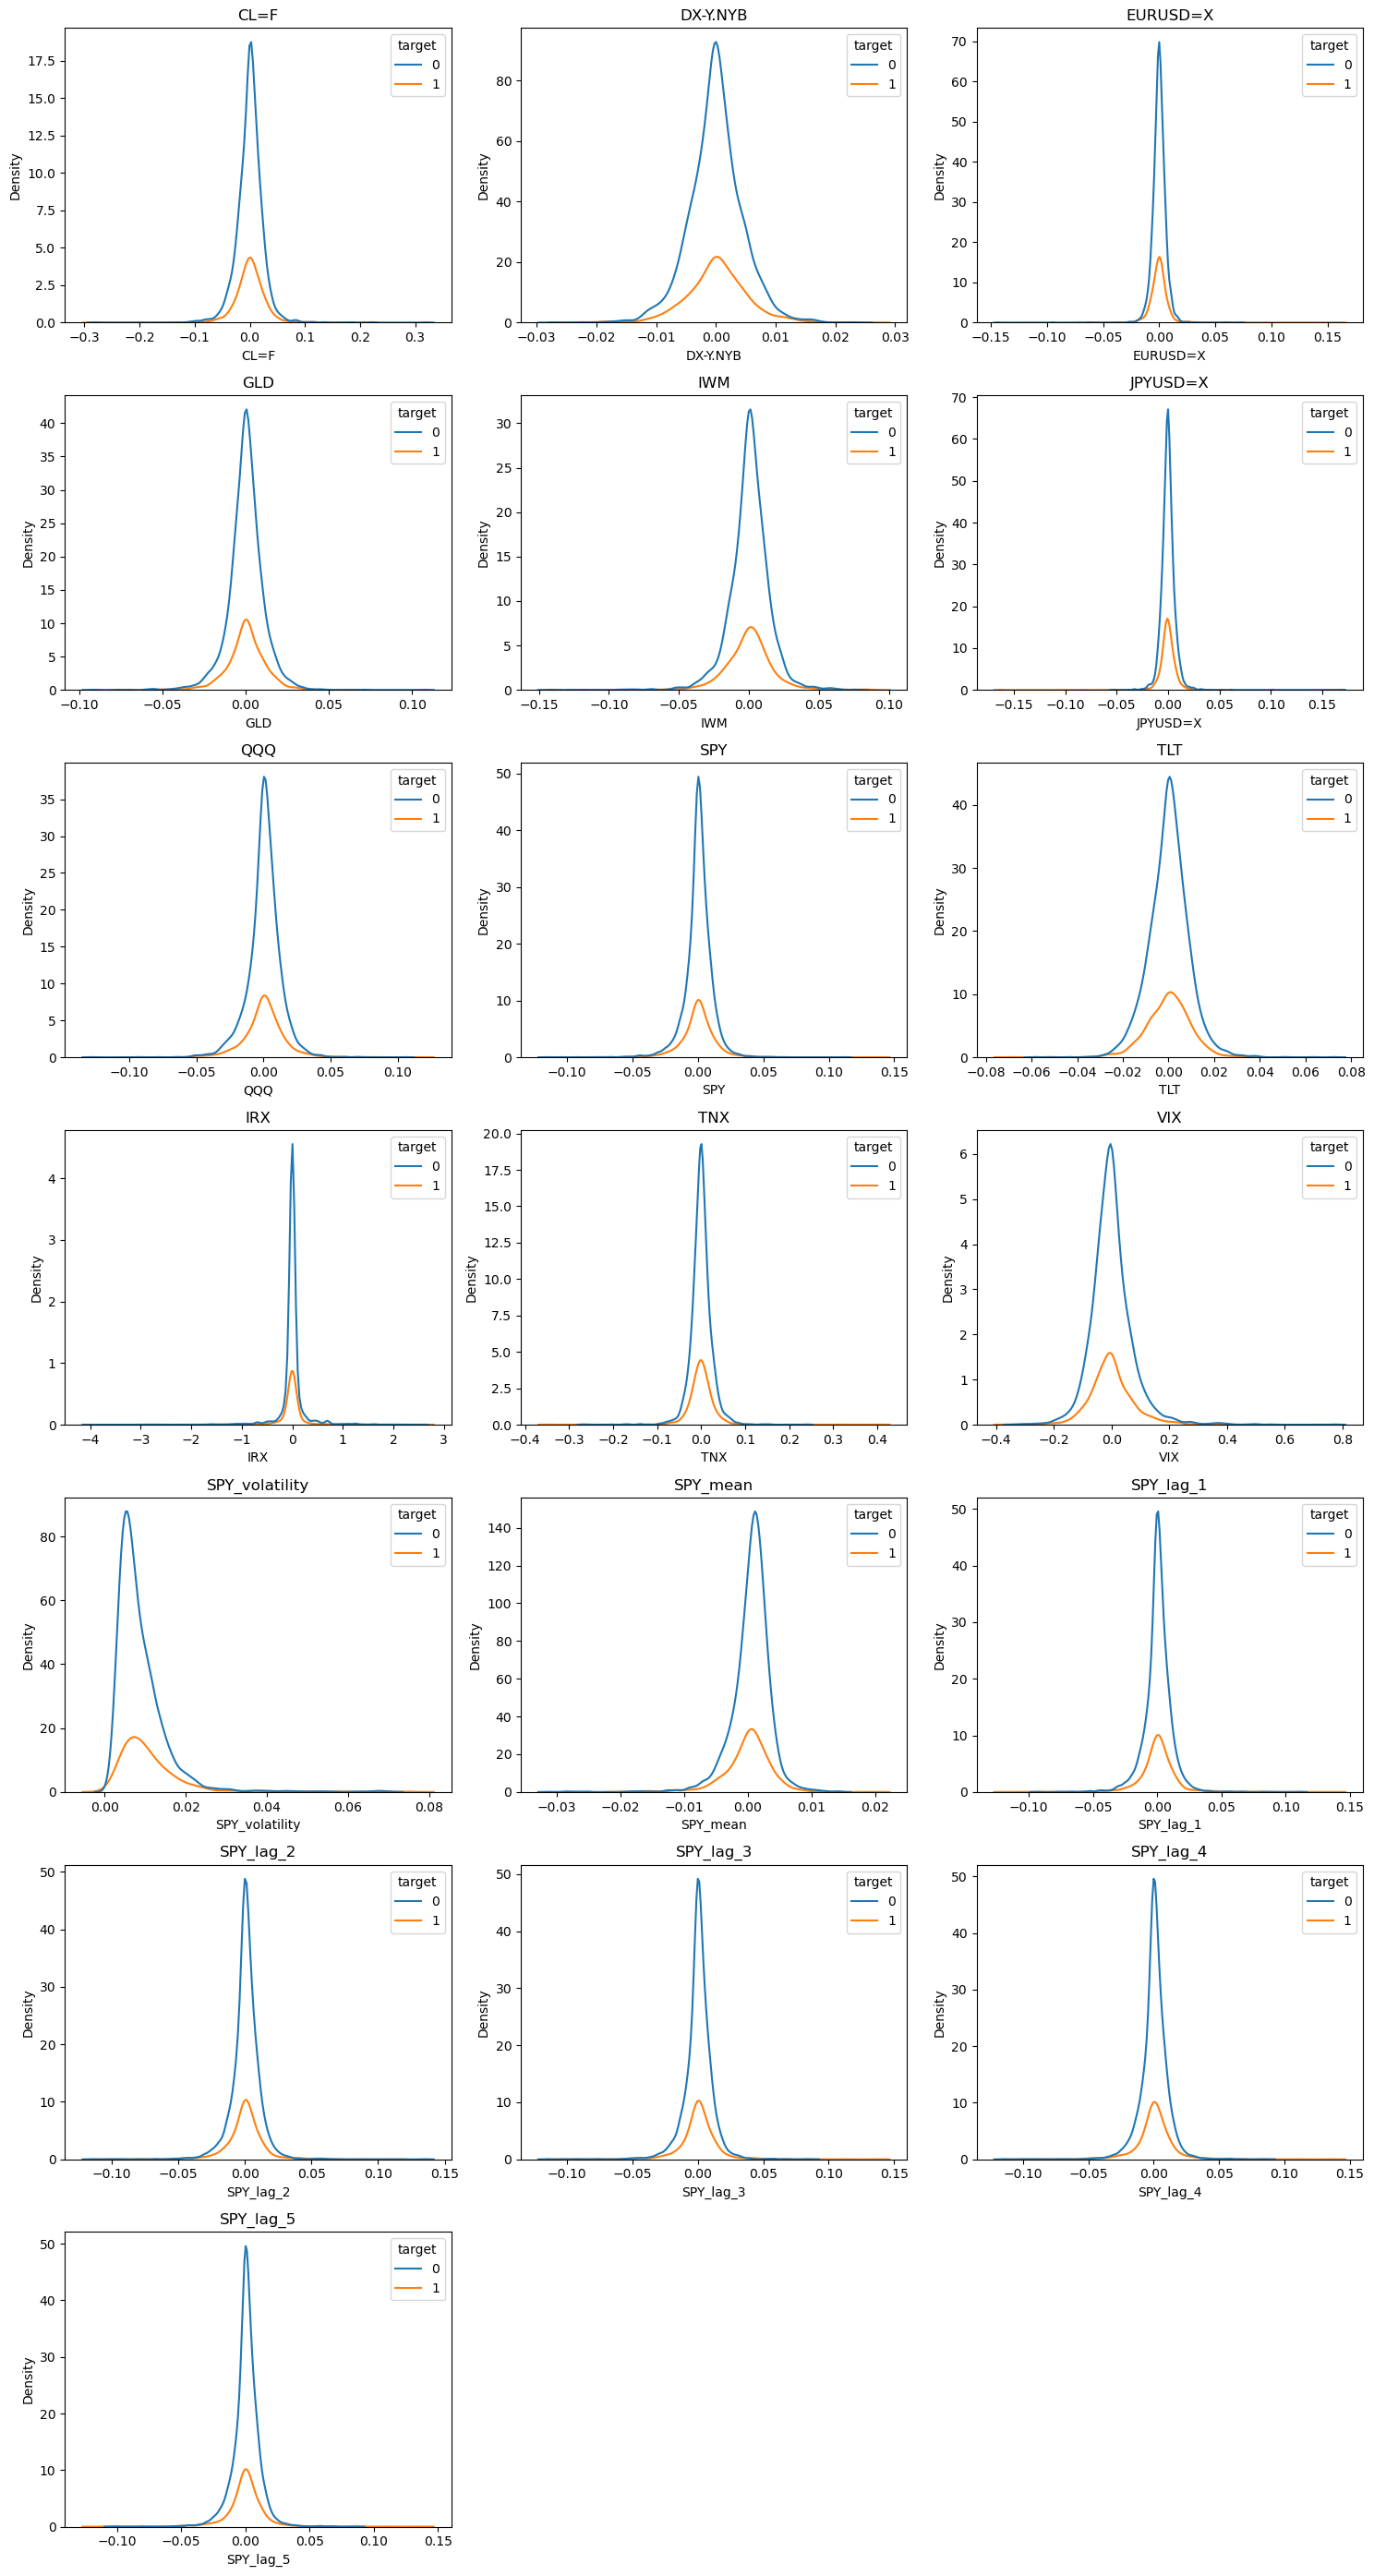

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

features = returns.columns.drop(['target'])

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=returns, x=col, hue='target', ax=axes[i])
    axes[i].set_title(col)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Basically, in the above graph, we are trying to see the distribution of the variables with respect to the target(crash, no crash)

In [16]:
returns.isnull().sum()
#derived features have missing values

CL=F              0
DX-Y.NYB          0
EURUSD=X          0
GLD               0
IWM               0
JPYUSD=X          0
QQQ               0
SPY               0
TLT               0
IRX               0
TNX               0
VIX               0
target            0
SPY_volatility    9
SPY_mean          9
SPY_lag_1         1
SPY_lag_2         2
SPY_lag_3         3
SPY_lag_4         4
SPY_lag_5         5
dtype: int64

graphs for LOG Returns

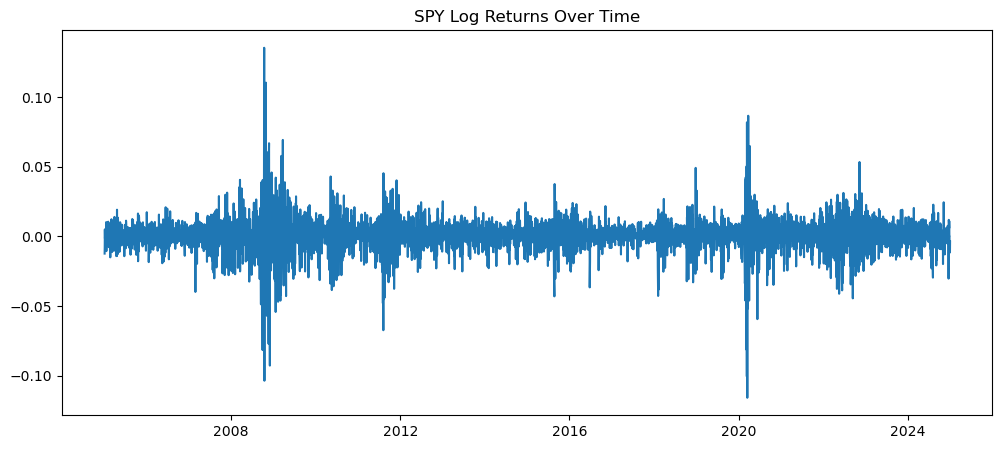

In [17]:
#Time Series Plot
plt.figure(figsize=(12,5))
plt.plot(returns.index, returns['SPY'])
plt.title("SPY Log Returns Over Time")
plt.show()

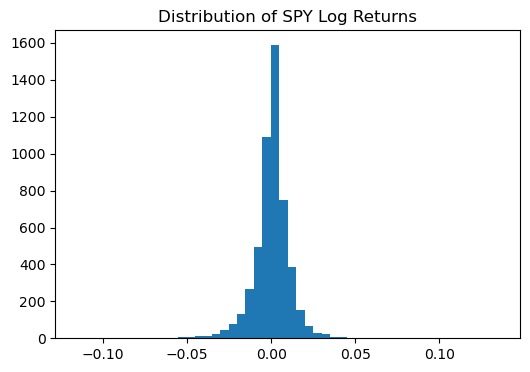

In [18]:
#Histogram
plt.figure(figsize=(6,4))
plt.hist(returns['SPY'], bins=50)
plt.title("Distribution of SPY Log Returns")
plt.show()

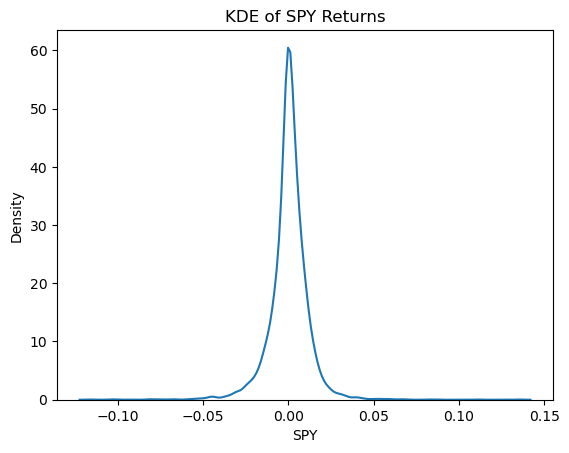

In [19]:
#KDE Plot
import seaborn as sns

sns.kdeplot(returns['SPY'])
plt.title("KDE of SPY Returns")
plt.show()

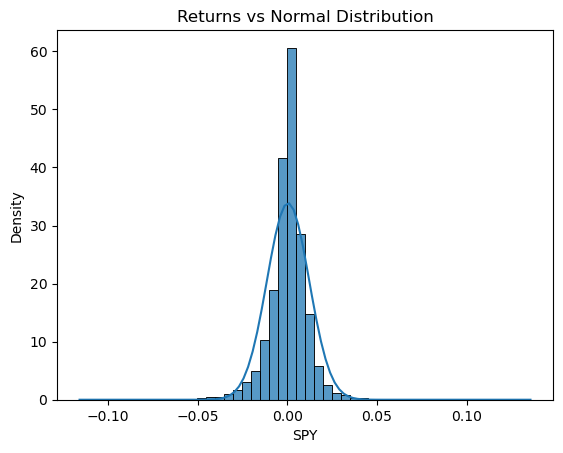

In [20]:
#Compare with Normal Distribution
from scipy.stats import norm

sns.histplot(returns['SPY'], bins=50, stat='density')
x = np.linspace(returns['SPY'].min(), returns['SPY'].max(), 100)
plt.plot(x, norm.pdf(x, returns['SPY'].mean(), returns['SPY'].std()))
plt.title("Returns vs Normal Distribution")
plt.show()

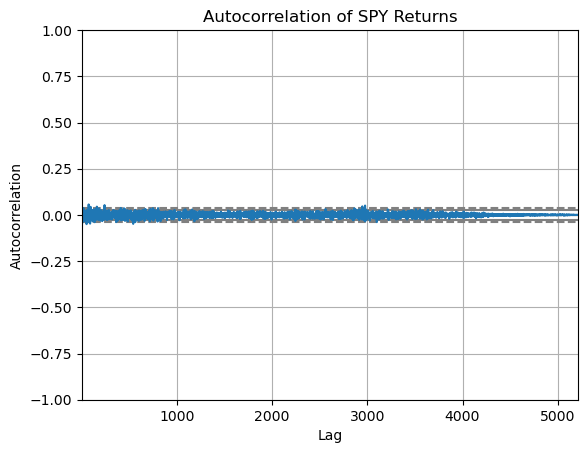

In [21]:
    #Autocorrelation
    from pandas.plotting import autocorrelation_plot

    autocorrelation_plot(returns['SPY'])
    plt.title("Autocorrelation of SPY Returns")
    plt.show()
    #Very low autocorrelation -> efficient markets

In [22]:
import pandas as pd
import numpy as np

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif

In [23]:
#Volatility, skewness, kurtosis
windows = [21, 63]
feature_list = []

for col in returns.columns:
    temp = pd.DataFrame(index=returns.index)
    
    for w in windows:
        roll = returns[col].rolling(w)
        
        temp[f'{col}_vol_{w}'] = roll.std()      # volatility
        temp[f'{col}_skew_{w}'] = roll.skew()    # skewness (vectorized)
        temp[f'{col}_kurt_{w}'] = roll.kurt()    # kurtosis (vectorized)
    
    feature_list.append(temp)

features = pd.concat(feature_list, axis=1)  # no fragmentation

In [24]:
def fast_entropy(arr, bins=30):
    arr = arr[~np.isnan(arr)]  # remove NaNs
    
    if len(arr) == 0:
        return np.nan  # nothing to compute
    
    hist, _ = np.histogram(arr, bins=bins, density=True)
    
    hist = hist[hist > 0]  # remove zero probabilities
    
    return -np.sum(hist * np.log(hist))
       

In [25]:
for col in returns.columns:
    for w in windows:
        values = returns[col].values
        ent = np.full(len(values), np.nan)
        
        for i in range(w, len(values)):
            ent[i] = fast_entropy(values[i-w:i])
        
        features[f'{col}_entropy_{w}'] = ent

In [26]:
#Hurst
def fast_hurst(ts):
    # skip flat series early
    if np.std(ts) < 1e-8:
        return np.nan
    
    lags = np.array([2, 5, 10, 15])  # reduced lags (BIG speed gain)
    
    tau = []
    for lag in lags:
        diff = ts[lag:] - ts[:-lag]
        std = np.std(diff)
        if std > 0:
            tau.append(std)
        else:
            tau.append(np.nan)
    
    tau = np.array(tau)
    
    valid = ~np.isnan(tau)
    
    if np.sum(valid) < 2:
        return np.nan
    
    try:
        poly = np.polyfit(np.log(lags[valid]), np.log(tau[valid]), 1)
        return poly[0]
    except:
        return np.nan

In [28]:
hurst_windows = [16, 64, 256]
for col in returns.columns:
    values = returns[col].values  # move outside loop
    
    for w in hurst_windows:
        hurst_vals = np.full(len(values), np.nan)
        
        for i in range(w, len(values)):
            hurst_vals[i] = fast_hurst(values[i-w:i])
        
        features[f'{col}_hurst_{w}'] = hurst_vals


C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\3190105195.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{col}_hurst_{w}'] = hurst_vals
C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\3190105195.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{col}_hurst_{w}'] = hurst_vals
C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\3190105195.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

In [30]:
def kl_div(p, q):
    p = p + 1e-10  # avoid log(0)
    q = q + 1e-10
    return np.sum(p * np.log(p / q))


for col in returns.columns:
    values = returns[col].values
    kl_vals = np.full(len(values), np.nan)
    
    for i in range(126, len(values)):
        short = values[i-21:i]
        long = values[i-126:i]
        
        # ✅ Remove NaNs
        short = short[~np.isnan(short)]
        long = long[~np.isnan(long)]
        
        # ✅ Skip if not enough data
        if len(short) < 10 or len(long) < 30:
            continue
        
        # ✅ Skip unstable windows
        if np.std(short) < 1e-8 or np.std(long) < 1e-8:
            continue
        
        # ✅ Histogram
        p_hist, _ = np.histogram(short, bins=30)
        q_hist, _ = np.histogram(long, bins=30)
        
        # ✅ Normalize
        p_hist = p_hist / np.sum(p_hist)
        q_hist = q_hist / np.sum(q_hist)
        
        kl_vals[i] = kl_div(p_hist, q_hist)
    
    features[f'{col}_kl'] = kl_vals

C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\779692694.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{col}_kl'] = kl_vals
C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\779692694.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f'{col}_kl'] = kl_vals
C:\Users\sivac\AppData\Local\Temp\ipykernel_24028\779692694.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

In [31]:
#Now we move to final dataset preparation.

In [32]:
features = features.ffill().dropna()
features = features.copy()  # defragment

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = pd.DataFrame(
    scaler.fit_transform(features),
    index=features.index,
    columns=features.columns
)

In [34]:
variance = features_scaled.var()
features_lv = features_scaled.loc[:, variance > 0.0001]

In [ ]:
print("Minimum values in each column:")
print(df.min())

In [36]:
# Step 1: log returns
log_returns = np.log(df / df.shift(1))

# Step 2: future 5-day return
h = 5
threshold = -0.01

future_return = log_returns['SPY'].rolling(window=h).sum().shift(-h)

# Step 3: binary target
y = (future_return <= threshold).astype(int)

# Step 4: clean
y = y.dropna()

c:\Users\sivac\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [37]:
corr_matrix = features_lv.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

features_final = features_lv.drop(columns=to_drop)
# 👉 ADD THESE LINES HERE
features_final = features_final.dropna()
y = y.loc[features_final.index]

In [ ]:
# Define a 5-day drawdown event
h = 5
delta = -0.01  # 1% or greater 5-day decline

spy_future_return = returns['SPY'].rolling(window=h).sum().shift(-h)

returns['target'] = (spy_future_return <= delta).astype(int)
returns = returns.dropna()

returns.columns